# 1. Preparando o Ambiente de Análise 🛠️

Nesta etapa inicial, **eu configurei** as ferramentas que usarei para inspecionar os dados. Importei bibliotecas essenciais de visualização (`seaborn`, `matplotlib`) e defini os caminhos relativos para garantir que o notebook encontre o arquivo CSV gerado pelo meu pipeline de engenharia de dados.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração de estilo visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminhos (ajustando para rodar de dentro da pasta notebooks)
PROCESSED_PATH = '../data/processed/dataset_espelhos.csv'
RAW_PATH = '../data/raw/'
    
print("Bibliotecas importadas e caminhos definidos.")

Bibliotecas importadas e caminhos definidos.


# 2. Carregamento do Dataset Processado 📂

Aqui, **carreguei o resultado final** da etapa de ingestão de dados. Meu objetivo foi confirmar se o script `run_ingestion.py` gerou o arquivo corretamente e visualizar as primeiras linhas para ter uma noção imediata da estrutura tabular que consegui extrair dos PDFs.

In [23]:
# Carregar o dataset gerado pelo pipeline
try:
    df = pd.read_csv(PROCESSED_PATH)
    print(f"✅ Dataset carregado com sucesso! Dimensões: {df.shape}")
except FileNotFoundError:
    print("❌ Arquivo não encontrado. Verifique se rodou o 'run_ingestion.py'.")

# Mostrar as primeiras linhas
df.head(25) # Mostra todos já que são poucos

✅ Dataset carregado com sucesso! Dimensões: (21, 14)


,Nome_Arquivo,Idade,Sexo,Justificativa_Internacao,Evolucao,Sinais_Vitais,Necessidade_Dialise,Sinais_Vitais_O2_Suporte,Instabilidade_Hemodinamica,Hemorragia_Ativa,Suspeita_Infecciosa,Oncologia_Fora_Perfil,Sinais_Gastro_Hepato,CID_10
0,CML.pdf,72,F,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,Data/Hora: 10/10/2025 10:14\n Profissional ...,"{'G_TDR': '1', 'F_Cardiaca': '83', 'F_Respirat...",1,1,1,0,0,0,1,R18
1,CWSS.pdf,42,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 08/10/2025 11:32\n P ...,"{'G_TDR': '3', 'F_Cardiaca': '0', 'F_Respirato...",1,0,0,0,0,0,1,C22
2,DJA.pdf,46,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 03/09/2025 13:17\n P ...,"{'G_TDR': '3', 'F_Cardiaca': '103', 'F_Respira...",0,0,0,0,0,0,0,K51
3,EAS.pdf,49,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 25/09/2025 13:26\n P ...,"{'G_TDR': '3', 'F_Cardiaca': '85', 'F_Respirat...",1,1,0,0,1,0,1,I85
4,EAS_Gastro.pdf,49,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 25/09/2025 13:26\n P ...,"{'G_TDR': '3', 'F_Cardiaca': '85', 'F_Respirat...",1,1,0,0,1,0,1,I85
5,EES.pdf,38,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,PACIENTE REFERE QUE HÁ 20 DIAS EVOLUIU COM QUA...,"{'G_TDR': '1', 'F_Cardiaca': '77', 'F_Respirat...",1,1,0,1,0,0,1,K51
6,EFC.pdf,29,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,"EVOLUO PACIENTE EM LEITO DE ALA AMARELA, ACOMP...","{'G_TDR': '3', 'F_Cardiaca': '75', 'F_Respirat...",1,0,1,0,0,0,1,R18
7,EJA.pdf,43,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,CONDIÇÕES QUE JUSTIFIQUEM A INTERNAÇÃO:\n P...,"{'G_TDR': '1', 'F_Cardiaca': None, 'F_Respirat...",1,1,0,1,0,0,1,K50
8,FAA.pdf,48,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,CLINICA E HEMODINAMICAMENTE ESTAVEL. SEM QUEIX...,"{'G_TDR': '3', 'F_Cardiaca': '78', 'F_Respirat...",1,0,1,1,0,0,0,K57
9,f_gastro.pdf,51,M,QUADRO CLÍNICO/PRINCIPAIS SINAIS E SINTOMAS:\n...,D/H: 23/12/2025 05:16\n P ...,"{'G_TDR': '3', 'F_Cardiaca': '93', 'F_Respirat...",0,1,0,0,0,0,1,NaN


# 3. Raio-X da Qualidade dos Dados (Valores Nulos) 🔍

Precisava entender a integridade dos dados extraídos. **Utilizei um mapa de calor (heatmap)** para visualizar onde estão os "buracos" (dados nulos).

* **Minha intenção:** Descobrir se falhas na extração de campos específicos (como Idade ou Texto Diagnóstico) são isoladas ou sistêmicas em todo o dataset.

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Nome_Arquivo                21 non-null     object
 1   Idade                       21 non-null     int64 
 2   Sexo                        21 non-null     object
 3   Justificativa_Internacao    21 non-null     object
 4   Evolucao                    21 non-null     object
 5   Sinais_Vitais               21 non-null     object
 6   Necessidade_Dialise         21 non-null     int64 
 7   Sinais_Vitais_O2_Suporte    21 non-null     int64 
 8   Instabilidade_Hemodinamica  21 non-null     int64 
 9   Hemorragia_Ativa            21 non-null     int64 
 10  Suspeita_Infecciosa         21 non-null     int64 
 11  Oncologia_Fora_Perfil       21 non-null     int64 
 12  Sinais_Gastro_Hepato        21 non-null     int64 
 13  CID_10             

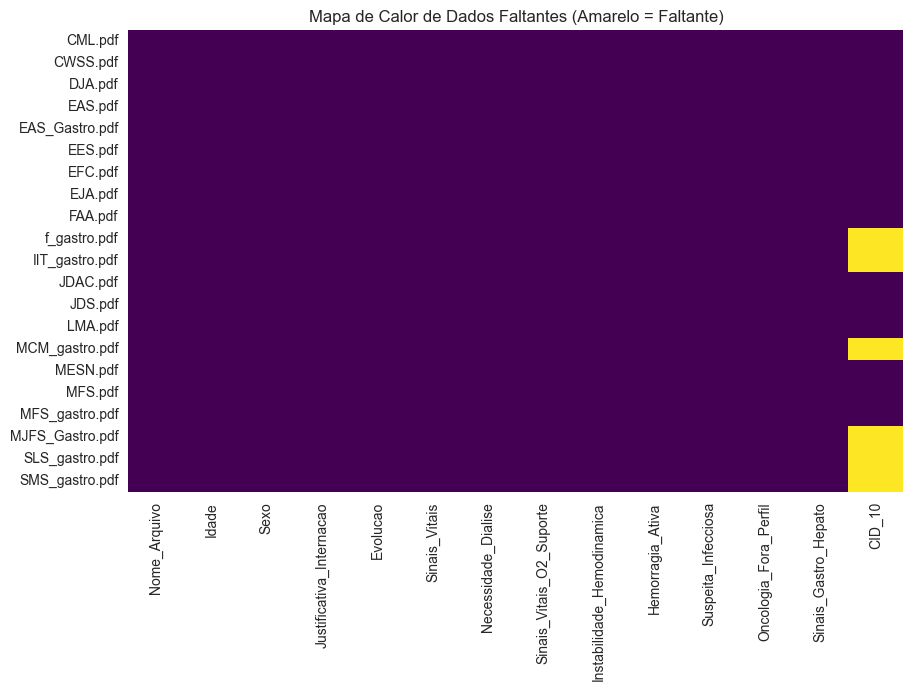

In [24]:
# Verificar tipos de dados e valores nulos
print("--- Informações do DataFrame ---")
df.info()

print("\n--- Contagem de Valores Nulos ---")
print(df.isnull().sum())

# Visualizar onde estão os nulos (Mapa de Calor)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=df['Nome_Arquivo'])
plt.title("Mapa de Calor de Dados Faltantes (Amarelo = Faltante)")
plt.show()

# 4. Investigação de Erros de Encoding (Artefatos de PDF) 🛑

Durante o desenvolvimento, **notei que alguns PDFs antigos** geravam caracteres estranhos como `(cid:`. Criei este filtro para quantificar quantos arquivos foram afetados por esse problema de *parsing*. Isso demonstra a "sujeira" real dos dados legados com a qual tive que lidar.

# 5. Validação das Flags Clínicas (Regras de Negócio) 🏥

Aqui, **plotei a distribuição** das principais variáveis de risco que meu algoritmo extraiu via *Regex*.

* **O que eu busquei validar:** Queria confirmar se o sistema estava conseguindo identificar corretamente pacientes com **Necessidade de Diálise** ou **Uso de O2**, que são os principais critérios de exclusão do protocolo.

Uma informação valiosa é saber quantos riscos cada paciente possui ao mesmo tempo. Isso indica a gravidade geral da base.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_13440\1822572384.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Total_Riscos', palette='Reds')


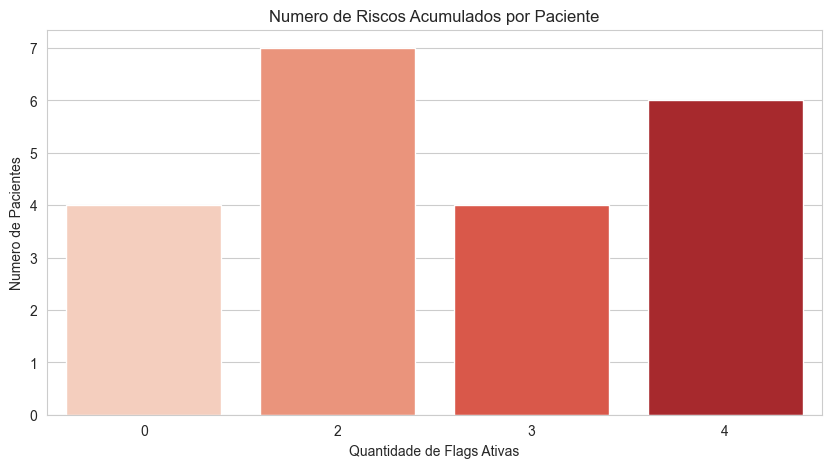

In [25]:
# Definir colunas de flag e validar presenca
flags = [
    'Necessidade_Dialise',
    'Sinais_Vitais_O2_Suporte',
    'Instabilidade_Hemodinamica',
    'Hemorragia_Ativa',
    'Suspeita_Infecciosa',
    'Oncologia_Fora_Perfil',
    'Sinais_Gastro_Hepato',
]
missing_flags = [col for col in flags if col not in df.columns]
if missing_flags:
    raise ValueError(f"Colunas de flag ausentes no dataset: {missing_flags}")

# Soma das flags de risco por paciente
df['Total_Riscos'] = df[flags].sum(axis=1)

# Coluna categorica para estratificar por perfil gastro/hepato
df['Perfil_Gastro'] = df['Sinais_Gastro_Hepato'].map({1: 'Perfil gastro', 0: 'Fora do perfil'}).fillna('Desconhecido')

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Total_Riscos', palette='Reds')
plt.title('Numero de Riscos Acumulados por Paciente')
plt.xlabel('Quantidade de Flags Ativas')
plt.ylabel('Numero de Pacientes')
plt.show()

# 6. Riscos por Perfil Gastro vs Fora do Perfil

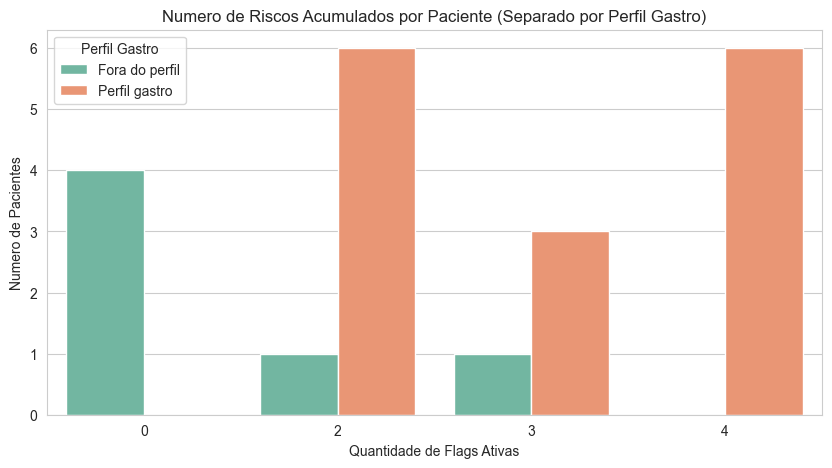

In [26]:
## Plotando a distribuicao de espelhos separando por perfil gastro vs fora do perfil
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Total_Riscos', hue='Perfil_Gastro', palette='Set2')
plt.title('Numero de Riscos Acumulados por Paciente (Separado por Perfil Gastro)')
plt.xlabel('Quantidade de Flags Ativas')
plt.ylabel('Numero de Pacientes')
plt.legend(title='Perfil Gastro')
plt.show()

C:\Users\gfasg\AppData\Local\Temp\ipykernel_13440\3213661097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tem_Flag_Risco', palette='Blues')


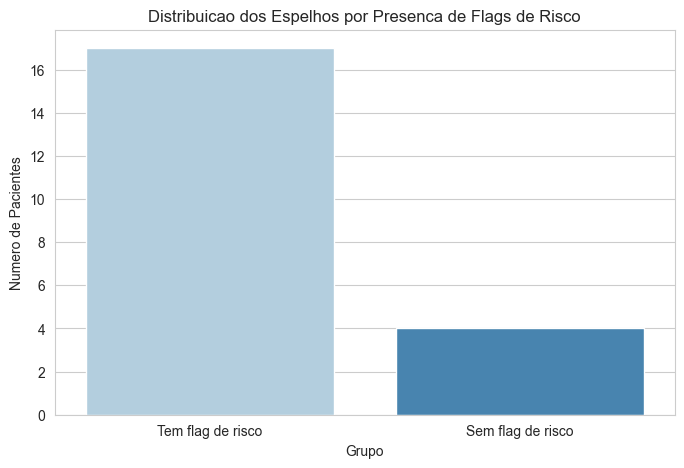

In [27]:
# Plotando a distribuicao dos espelhos para 'Tem flags de risco' vs 'Nao tem flags de risco'
df['Tem_Flag_Risco'] = df['Total_Riscos'].apply(lambda v: 'Tem flag de risco' if v > 0 else 'Sem flag de risco')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Tem_Flag_Risco', palette='Blues')
plt.title('Distribuicao dos Espelhos por Presenca de Flags de Risco')
plt.xlabel('Grupo')
plt.ylabel('Numero de Pacientes')
plt.show()

C:\Users\gfasg\AppData\Local\Temp\ipykernel_13440\3622491785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Perfil_Gastro', palette='Set1')


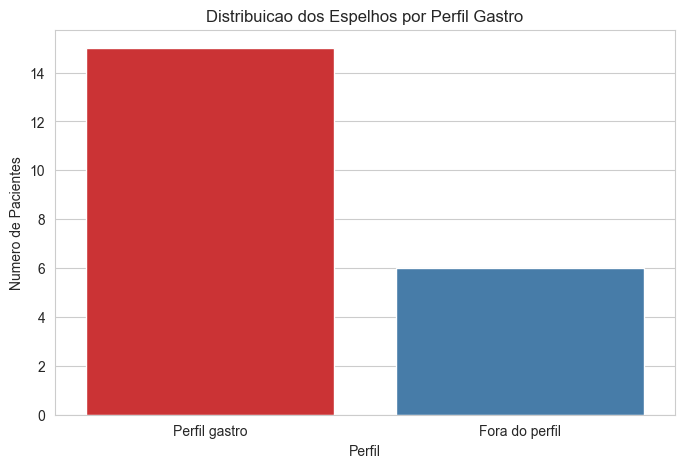

In [28]:
## Plotando  a distribuição dos espelhos que são do perfil gastro vs fora do perfil.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Perfil_Gastro', palette='Set1')
plt.title('Distribuicao dos Espelhos por Perfil Gastro')
plt.xlabel('Perfil')
plt.ylabel('Numero de Pacientes')
plt.show()

C:\Users\gfasg\AppData\Local\Temp\ipykernel_13440\2027480154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flags_sum.index, y=flags_sum.values, palette='viridis')


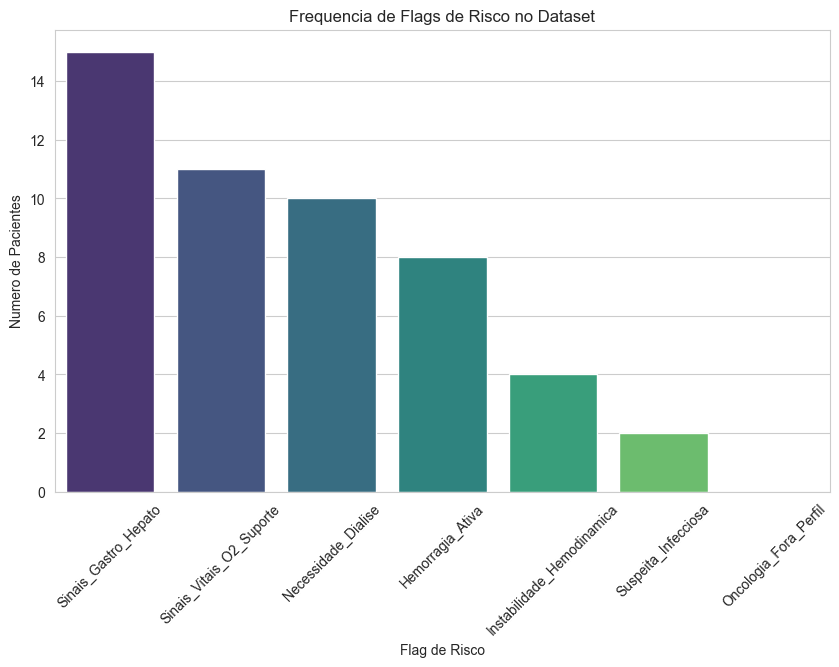

In [29]:
##Plotagem de flags mais frequentes
flags_sum = df[flags].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=flags_sum.index, y=flags_sum.values, palette='viridis')
plt.title('Frequencia de Flags de Risco no Dataset')
plt.xlabel('Flag de Risco')
plt.ylabel('Numero de Pacientes')
plt.xticks(rotation=45)
plt.show()
